GOAL: Handle class imbalance, tune models, and train stronger fraud models.

Step1 - Check baseline fraud ratio

In [2]:
import pandas as pd 

df = pd.read_csv("../data/processed_fraud_dataset.csv")

df.head()
df.info()

df["is_fraud"].value_counts(normalize=True) * 100

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 12 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   category               1296675 non-null  str    
 1   amt                    1296675 non-null  float64
 2   gender                 1296675 non-null  str    
 3   city_pop               1296675 non-null  int64  
 4   job                    1296675 non-null  str    
 5   is_fraud               1296675 non-null  int64  
 6   transaction_hour       1296675 non-null  int64  
 7   transaction_day        1296675 non-null  int64  
 8   transaction_month      1296675 non-null  int64  
 9   transaction_dayofweek  1296675 non-null  int64  
 10  age                    1296675 non-null  int64  
 11  distance_km            1296675 non-null  float64
dtypes: float64(2), int64(7), str(3)
memory usage: 118.7 MB


is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64

Separate Features and Target

In [3]:
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]

Identify Categorical and Numerical Columns

In [4]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

print(categorical_cols)
print(numerical_cols)

Index(['category', 'gender', 'job'], dtype='str')
Index(['amt', 'city_pop', 'transaction_hour', 'transaction_day',
       'transaction_month', 'transaction_dayofweek', 'age', 'distance_km'],
      dtype='str')


C:\Users\vedant\AppData\Local\Temp\ipykernel_24068\4123245944.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns


Train/Test Split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

A - Numerical Transformer

In [6]:
from sklearn.preprocessing import StandardScaler

num_transformer = StandardScaler()

B - Categorical Transformer

In [7]:
from sklearn.preprocessing import OneHotEncoder

cat_transformer = OneHotEncoder(handle_unknown="ignore")

C - Combine

In [8]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, numerical_cols),
        ("cat", cat_transformer, categorical_cols)
    ]
)


Step2 - Use class-balanced Logistic Regression

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

balanced_log_model = Pipeline(steps=[
    ("preprocessor", preprocessor), 
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000, n_jobs=-1))
])

balanced_log_model.fit(X_train, y_train)

balanced_log_pred = balanced_log_model.predict(X_test)

c:\Users\vedant\Projects\fraud-risk-platform\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Evaluate:

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test, balanced_log_pred))
print(confusion_matrix(y_test, balanced_log_pred))

balanced_log_prob = balanced_log_model.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, balanced_log_prob))

              precision    recall  f1-score   support

           0       1.00      0.88      0.94    257834
           1       0.04      0.80      0.07      1501

    accuracy                           0.88    259335
   macro avg       0.52      0.84      0.51    259335
weighted avg       0.99      0.88      0.93    259335

[[228056  29778]
 [   306   1195]]
ROC-AUC: 0.9291258943200248


Step 3 - Try Random Forest with balanced class weight

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_balanced = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=50, max_depth=15, min_samples_split=50,
        class_weight="balanced", n_jobs=-1, random_state=42
    ))
])

rf_balanced.fit(X_train, y_train)

rf_balanced_pred = rf_balanced.predict(X_test)

Evaluate: 

In [12]:
print(classification_report(y_test, rf_balanced_pred))
print(confusion_matrix(y_test, rf_balanced_pred))

rf_balanced_prob = rf_balanced.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, rf_balanced_prob))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    257834
           1       0.22      0.81      0.34      1501

    accuracy                           0.98    259335
   macro avg       0.61      0.89      0.67    259335
weighted avg       0.99      0.98      0.99    259335

[[253464   4370]
 [   292   1209]]
ROC-AUC: 0.9774653580646688


Step 4 - Threshold Tuning - Default threshold is usually: 0.5, but fraud detection often needs a lower threshold

In [13]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

for t in thresholds:
    y_pred_t = (balanced_log_prob >= t).astype(int)

    print("Threshold:", t)
    print("Precision:", precision_score(y_test, y_pred_t))
    print("Recall:", recall_score(y_test, y_pred_t))
    print("F1-Score:", f1_score(y_test, y_pred_t))
    print("-" * 30)

Threshold: 0.1
Precision: 0.010214399207610244
Recall: 0.9893404397068621
F1-Score: 0.020220037580675906
------------------------------
Threshold: 0.2
Precision: 0.014188388625592418
Recall: 0.9573617588274483
F1-Score: 0.027962366585263812
------------------------------
Threshold: 0.3
Precision: 0.01902193301653895
Recall: 0.8880746169220519
F1-Score: 0.0372460811981335
------------------------------
Threshold: 0.4
Precision: 0.0261885323117503
Recall: 0.8334443704197202
F1-Score: 0.05078140856504973
------------------------------
Threshold: 0.5
Precision: 0.03858199076615117
Recall: 0.7961359093937375
F1-Score: 0.07359733940998953
------------------------------


Note: 1) Lower threshold -> higher recall, more false positives

2) Higher threshold -> higher precision, more missed fraud

Step 5 - Precision-Recall Curve

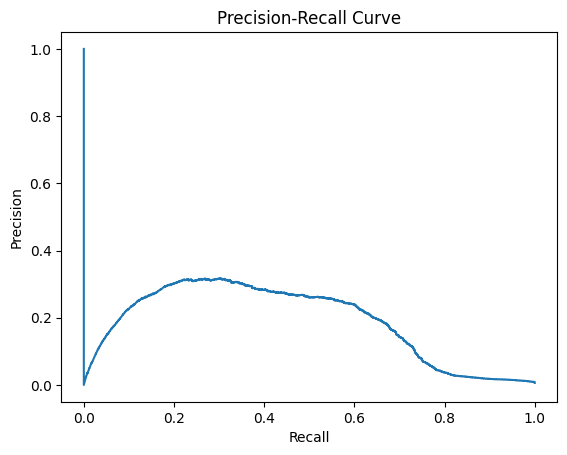

In [14]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(
    y_test, balanced_log_prob
)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

For imbalanced fraud detection, PR curve is usually more useful than plain accuracy.

Step 6: Try XGBoost

In [15]:
from xgboost import XGBClassifier

xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1, subsample=0.8,
        colsample_bytree=0.8, eval_metric="logloss", n_jobs=-1, random_state=42
    ))
])

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

Evaluate:

In [16]:
print(classification_report(y_test, xgb_pred))
print(confusion_matrix(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.94      0.78      0.85      1501

    accuracy                           1.00    259335
   macro avg       0.97      0.89      0.93    259335
weighted avg       1.00      1.00      1.00    259335

[[257759     75]
 [   325   1176]]
ROC-AUC: 0.9969028510599838


Step 7: Handle imbalance in XGBoost

Calculate imbalance ratio:

In [17]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos
scale_pos_weight

np.float64(171.74604496253122)

Train balanced XGBoost

In [18]:
xgb_balanced = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=150, max_depth=5, learning_rate=0.08, sub_sample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight, eval_metric="logloss", n_jobs=-1, random_state=42
    ))
])

xgb_balanced.fit(X_train, y_train)

xgb_balanced_pred = xgb_balanced.predict(X_test)
xgb_balanced_prob = xgb_balanced.predict_proba(X_test)[:, 1]

Evaluate:

In [19]:
print(classification_report(y_test, xgb_balanced_pred))
print(confusion_matrix(y_test, xgb_balanced_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_balanced_prob))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    257834
           1       0.24      0.97      0.39      1501

    accuracy                           0.98    259335
   macro avg       0.62      0.98      0.69    259335
weighted avg       1.00      0.98      0.99    259335

[[253302   4532]
 [    44   1457]]
ROC-AUC: 0.9979097053376307


Step 8: Create comparision table

In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

results = []

def add_result(name, y_pred, y_prob):
    results.append({
        "model": name,
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob)
    })

add_result("Balanced Logistic Regression", balanced_log_pred, balanced_log_prob)
add_result("Balanced Random Forest", rf_balanced_pred, rf_balanced_prob)
add_result("XGBoost", xgb_pred, xgb_prob)
add_result("Balanced XGBoost", xgb_balanced_pred, xgb_balanced_prob)

results_df = pd.DataFrame(results)
results_df.sort_values(by="f1", ascending=False)

,model,precision,recall,f1,roc_auc
2,XGBoost,0.940048,0.783478,0.854651,0.996903
3,Balanced XGBoost,0.243279,0.970686,0.389052,0.997910
1,Balanced Random Forest,0.216706,0.805463,0.341525,0.977465
0,Balanced Logistic Regression,0.038582,0.796136,0.073597,0.929126


Step 9: Save best model , choose based on fraud-class F1/recall:

In [21]:
import joblib 

joblib.dump(xgb_model, "../models/xgb_model.pkl")

['../models/xgb_model.pkl']